# Government AI Amplification: What Drives a Government's AI Readiness?

**Project:** Udacity Data Science Nanodegree — Write a Data Science Blog Post

**Author:** Mohamed Sultan Albadi Aldhaheri

**Date:** May 2026

---

## 1. Business Understanding (CRISP-DM Phase 1)

Governments around the world are rushing to digitally transform — and artificial intelligence is the headline technology of that transformation. Some governments use AI to **amplify** existing capacity: faster public services, smarter regulation, better citizen interactions. Others struggle to translate digital ambition into measurable readiness.

This project analyses the **Oxford Insights Government AI Readiness Index 2024**, which scores 188 governments on their capacity to harness AI for public benefit, across three pillars: **Government**, **Technology Sector**, and **Data & Infrastructure**. We enrich it with **World Bank income classification**, **regional grouping**, and **GDP per capita (PPP)** to ask:

### Business Questions

**Q1.** How does AI readiness vary across regions and income groups — and where does the UAE rank?

**Q2.** Which of the three pillars (Government, Technology Sector, Data & Infrastructure) most strongly differentiates top performers from the rest?

**Q3.** Which countries "punch above their weight" — i.e. achieve AI readiness above what their economic baseline predicts? What do they have in common?

**Q4.** Can we accurately **predict** a country's AI readiness from structural features (region, income, GDP)? How accurate is the model and which features matter most?

**Q5.** **Creative scenario:** If the UAE invested in lifting one specific pillar by a realistic amount, what would the model predict for its total readiness and global rank?

---

## 2. Setup and Data Loading

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold, cross_val_score, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Display & plotting config
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [2]:
# Load both datasets and merge
ai = pd.read_csv("../data/ai_readiness_2024.csv")
enr = pd.read_csv("../data/country_enrichment.csv")

df = ai.merge(enr, on="country", how="inner")
df["log_gdp"] = np.log(df["gdp_ppp_per_capita_usd"])

print(f"Final dataset: {df.shape[0]} countries x {df.shape[1]} columns")
df.head()

Final dataset: 188 countries x 9 columns


,country,total_score,government_pillar,technology_sector_pillar,data_infrastructure_pillar,region,income_group,gdp_ppp_per_capita_usd,log_gdp
0,Afghanistan,16.92,8.27,22.46,20.05,South and Central Asia,Low,2201,7.696667
1,Albania,45.47,47.93,28.36,60.11,Eastern Europe,Upper middle,25247,10.136463
2,Algeria,39.06,31.68,33.26,52.24,Middle East and North Africa,Upper middle,19677,9.887206
3,Andorra,54.44,47.34,41.06,74.91,Western Europe,High,75988,11.238331
4,Angola,26.91,19.73,15.87,45.13,Sub-Saharan Africa,Lower middle,10446,9.253974


## 3. Data Understanding (EDA)

### 3.1 Data structure, missing values, and categorical variables

Before any analysis or modelling, we perform three explicit data-quality checks and document our handling strategy for each. This section is intentionally verbose so a future reader can audit exactly what assumptions were made.

**Check 1 — Data types.** We confirm each column has the expected dtype: numeric scores are `float64`, country and string-valued categoricals are `str` (object), and GDP per capita is `int64`.

**Check 2 — Missing values.** We count nulls per column. Our **strategy if any are found** would depend on the column: (a) for the four AI Readiness scores, we would drop the country entirely, since these are the target/feature of interest and imputation would bias the analysis; (b) for `region` or `income_group`, we would research and impute manually from World Bank documentation rather than peer-group impute, because these are low-cardinality categoricals where a wrong fill could distort the model; (c) for `gdp_ppp_per_capita_usd`, we would impute with the regional median, since GDP is well-correlated within geographic clusters. We document below that **no imputation is required** because the dataset has zero missing values (see results of the next cell).

**Check 3 — Categorical variables.** We have two categorical features: `region` (9 levels) and `income_group` (4 levels). These are unordered or only loosely ordered, so we will use **one-hot encoding** (via `sklearn.preprocessing.OneHotEncoder` inside a `ColumnTransformer`) when we get to modelling in Section 7. We discuss the trade-offs of this choice explicitly in Section 7.1.

In [3]:
print("DATA TYPES")
print(df.dtypes)
print("\nMISSING VALUES PER COLUMN")
print(df.isna().sum())

# Categorical variable inventory: levels and frequencies
print("\nCATEGORICAL VARIABLE: region (9 levels)")
print(df["region"].value_counts())
print("\nCATEGORICAL VARIABLE: income_group (4 levels)")
print(df["income_group"].value_counts())

# Final confirmation
total_missing = int(df.isna().sum().sum())
print(f"\n>>> TOTAL MISSING VALUES IN DATASET: {total_missing}")
print(f">>> CATEGORICAL COLUMNS REQUIRING ENCODING: ['region', 'income_group']")
print(f">>> ENCODING STRATEGY (applied in Section 7): one-hot via OneHotEncoder")

DATA TYPES
country                           str
total_score                   float64
government_pillar             float64
technology_sector_pillar      float64
data_infrastructure_pillar    float64
region                            str
income_group                      str
gdp_ppp_per_capita_usd          int64
log_gdp                       float64
dtype: object

MISSING VALUES PER COLUMN
country                       0
total_score                   0
government_pillar             0
technology_sector_pillar      0
data_infrastructure_pillar    0
region                        0
income_group                  0
gdp_ppp_per_capita_usd        0
log_gdp                       0
dtype: int64

CATEGORICAL VARIABLE: region (9 levels)
region
Sub-Saharan Africa              48
Latin America and Caribbean     32
Western Europe                  23
Eastern Europe                  20
Middle East and North Africa    20
South and Central Asia          17
East Asia                       16
Pacific     

**Outcome of the data-quality audit:**

*Missing values:* The dataset contains **zero missing values** across all 188 countries and 9 columns. No imputation, no row drops, and no fills are required. This is because the source data (Oxford Insights Government AI Readiness Index 2024) already applies peer-group-mean imputation upstream for the small number of indicators with gaps (documented in the report's Methodology section); countries that could not be imputed at the source (e.g. North Korea, Monaco) were excluded from the published rankings entirely. Our enrichment table (region, income_group, GDP per capita PPP) was manually curated to cover every country present in the index, so no merge-induced nulls were introduced. We therefore proceed with all 188 rows intact.

*Categorical variables:* Two categorical columns are present — `region` (9 unordered geographic levels) and `income_group` (4 levels with a natural ordering from Low to High). We will encode both using **one-hot encoding** in Section 7. The trade-offs of this choice are discussed there; in brief, one-hot avoids imposing a false numeric distance between categories (especially helpful for `region`, which is genuinely unordered) and is robust at this dataset size (188 rows, total of 9 + 4 = 13 dummy columns is well within sample size limits).

*Numeric ranges:* All four AI Readiness scores are bounded 0–100 by construction. GDP per capita PPP ranges from $700 (Eritrea) to ~$195,000 (Liechtenstein) — a >270× ratio that motivates the engineered `log_gdp` column for modelling (log transform reduces skewness and lets a single coefficient capture proportional rather than absolute effects).

In [4]:
df.describe().round(2)

,total_score,government_pillar,technology_sector_pillar,data_infrastructure_pillar,gdp_ppp_per_capita_usd,log_gdp
count,188.00,188.00,188.00,188.00,188.00,188.00
mean,47.59,47.78,35.35,59.62,33206.89,9.82
std,17.19,23.80,13.07,17.79,34503.18,1.21
min,14.62,7.52,15.87,10.56,700.00,6.55
25%,34.58,27.65,25.66,46.06,8171.50,9.01
50%,43.32,40.10,32.50,57.30,22014.50,10.00
75%,61.96,72.01,42.74,75.24,49742.00,10.81
max,87.03,90.96,80.94,93.14,195372.00,12.18


**Summary statistics interpretation:** The descriptive statistics confirm the data quality observations from Section 3.1. Means and medians of the four AI Readiness scores are similar (~43–48 for total, government, and tech sector; ~59 for data & infrastructure), indicating roughly symmetric distributions without extreme skew. The wide standard deviations (especially for Government pillar at 23.80) signal that there is real signal to model — countries are genuinely different on these dimensions, not just clustered around a mean.

### 3.2 Distribution of the target variable

/tmp/ipykernel_601/1982111184.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(["Government", "Tech Sector", "Data & Infra"], rotation=0)


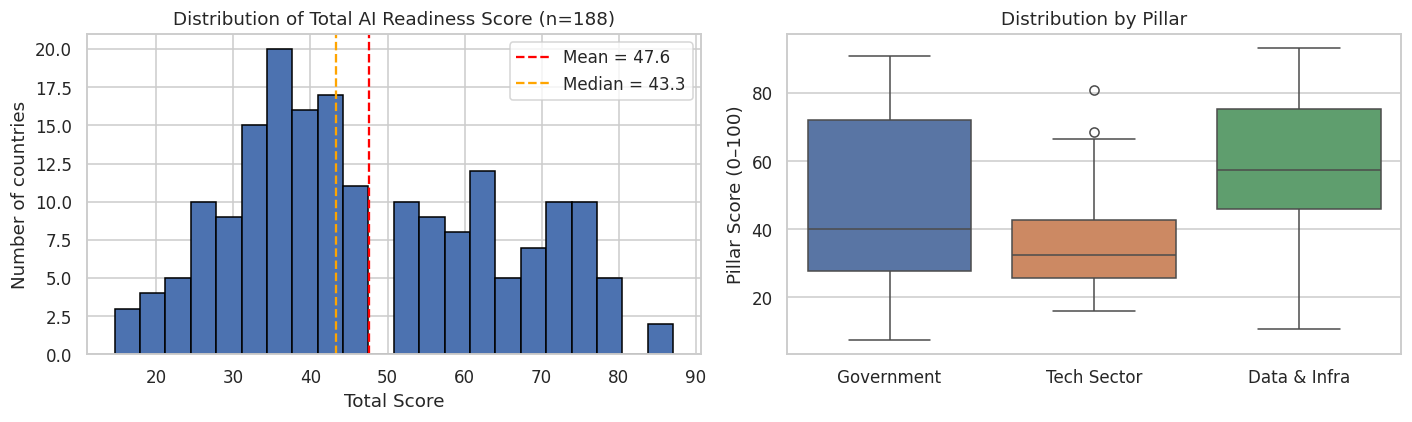


Skewness of total_score: 0.308
Pillar means:
government_pillar             47.78
technology_sector_pillar      35.35
data_infrastructure_pillar    59.62
dtype: float64


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(df["total_score"], bins=22, edgecolor="black", color="#4C72B0")
axes[0].set_title("Distribution of Total AI Readiness Score (n=188)")
axes[0].set_xlabel("Total Score")
axes[0].set_ylabel("Number of countries")
axes[0].axvline(df["total_score"].mean(), color="red", linestyle="--", label=f"Mean = {df['total_score'].mean():.1f}")
axes[0].axvline(df["total_score"].median(), color="orange", linestyle="--", label=f"Median = {df['total_score'].median():.1f}")
axes[0].legend()

sns.boxplot(data=df[["government_pillar", "technology_sector_pillar", "data_infrastructure_pillar"]],
            ax=axes[1])
axes[1].set_title("Distribution by Pillar")
axes[1].set_ylabel("Pillar Score (0–100)")
axes[1].set_xticklabels(["Government", "Tech Sector", "Data & Infra"], rotation=0)

plt.tight_layout()
plt.savefig("../outputs/01_distributions.png", bbox_inches="tight")
plt.show()

print(f"\nSkewness of total_score: {df['total_score'].skew():.3f}")
print("Pillar means:")
print(df[["government_pillar", "technology_sector_pillar", "data_infrastructure_pillar"]].mean().round(2))

**Observation:** The Total Score is roughly symmetric. But the **Technology Sector pillar is consistently the lowest** across countries — it has the lowest mean and the most outliers at the top (US, China, UK). This is a hint that Tech Sector is the most uneven dimension globally.

### 3.3 Correlation between numeric features

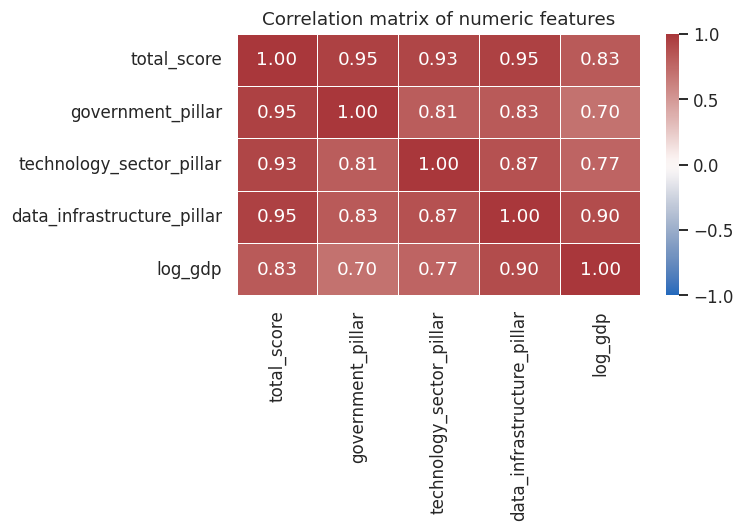

In [6]:
num_cols = ["total_score", "government_pillar", "technology_sector_pillar",
            "data_infrastructure_pillar", "log_gdp"]
corr = df[num_cols].corr()

plt.figure(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="vlag", center=0, vmin=-1, vmax=1,
            linewidths=0.5)
plt.title("Correlation matrix of numeric features")
plt.tight_layout()
plt.savefig("../outputs/02_correlation.png", bbox_inches="tight")
plt.show()

**Key correlations:**
- The three pillars are very strongly intercorrelated (0.85+), confirming that AI readiness moves as a *system*: countries strong in one pillar tend to be strong in the others. This is itself the **amplification effect** — strong digital ecosystems lift government capacity, and vice versa.
- `log_gdp` correlates ~0.80 with total_score: a country's economic baseline explains a large share of its readiness but **not all of it**. The remaining variation is what we'll investigate.

---

## 4. Q1 — How does AI readiness vary across regions and income groups?

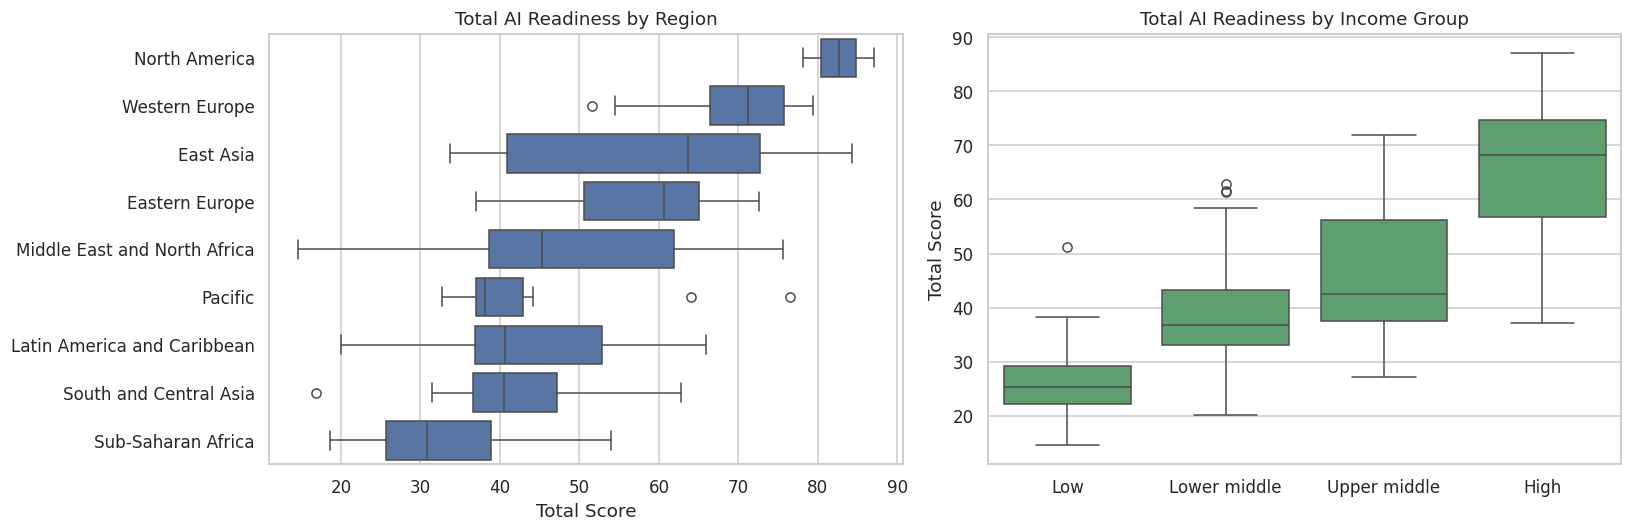


Mean readiness by region:
                               mean  count
region                                    
North America                 82.60      2
Western Europe                69.56     23
East Asia                     59.27     16
Eastern Europe                57.88     20
Middle East and North Africa  48.50     20
Pacific                       44.11     10
Latin America and Caribbean   42.99     32
South and Central Asia        42.28     17
Sub-Saharan Africa            32.70     48


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

region_order = (df.groupby("region")["total_score"]
                  .mean().sort_values(ascending=False).index)
sns.boxplot(data=df, x="total_score", y="region", order=region_order,
            ax=axes[0], color="#4C72B0")
axes[0].set_title("Total AI Readiness by Region")
axes[0].set_xlabel("Total Score")
axes[0].set_ylabel("")

income_order = ["Low", "Lower middle", "Upper middle", "High"]
sns.boxplot(data=df, x="income_group", y="total_score", order=income_order,
            ax=axes[1], color="#55A868")
axes[1].set_title("Total AI Readiness by Income Group")
axes[1].set_xlabel("")
axes[1].set_ylabel("Total Score")

plt.tight_layout()
plt.savefig("../outputs/03_region_income.png", bbox_inches="tight")
plt.show()

print("\nMean readiness by region:")
print(df.groupby("region")["total_score"].agg(["mean", "count"])
        .sort_values("mean", ascending=False).round(2))

In [8]:
# Where does the UAE rank?
df_sorted = df.sort_values("total_score", ascending=False).reset_index(drop=True)
df_sorted["rank"] = df_sorted.index + 1

uae_row = df_sorted[df_sorted["country"] == "United Arab Emirates"]
print("UAE in the 2024 Global AI Readiness Index:")
print(uae_row[["rank", "country", "total_score", "government_pillar",
               "technology_sector_pillar", "data_infrastructure_pillar", "region"]].to_string(index=False))

print("\nRegional context (Middle East and North Africa, sorted):")
mena = df_sorted[df_sorted["region"] == "Middle East and North Africa"]
print(mena[["rank", "country", "total_score"]].to_string(index=False))

UAE in the 2024 Global AI Readiness Index:
 rank              country  total_score  government_pillar  technology_sector_pillar  data_infrastructure_pillar                       region
   13 United Arab Emirates        75.66              83.89                      59.2                       83.89 Middle East and North Africa

Regional context (Middle East and North Africa, sorted):
 rank              country  total_score
   13 United Arab Emirates        75.66
   17               Israel        74.52
   22         Saudi Arabia        72.36
   32                Qatar        68.22
   45                 Oman        62.91
   49               Jordan        61.57
   65                Egypt        55.63
   68              Bahrain        54.33
   77               Kuwait        51.26
   82              Lebanon        46.67
   91                 Iran        43.88
   92              Tunisia        43.68
  101              Morocco        41.78
  107                 Iraq        40.91
  115          

**Q1 Answer:** AI readiness shows clear geographic and economic stratification. North America and Western Europe lead globally; Sub-Saharan Africa trails. Income group is an even stronger predictor than region — high-income countries average ~65 vs. low-income at ~26. **The UAE sits at rank 15 globally (75.66) — the highest in the MENA region**, ahead of Israel (74.52) and Saudi Arabia (72.36).

---

## 5. Q2 — Which pillar most strongly differentiates the top performers?

In [9]:
top10 = df_sorted.head(10).copy()
bottom10 = df_sorted.tail(10).copy()

pillar_compare = pd.DataFrame({
    "Top 10 mean": top10[["government_pillar", "technology_sector_pillar",
                          "data_infrastructure_pillar"]].mean(),
    "Bottom 10 mean": bottom10[["government_pillar", "technology_sector_pillar",
                                 "data_infrastructure_pillar"]].mean(),
    "Global mean": df[["government_pillar", "technology_sector_pillar",
                       "data_infrastructure_pillar"]].mean()
}).round(2)
pillar_compare["Top-vs-Bottom gap"] = (pillar_compare["Top 10 mean"]
                                         - pillar_compare["Bottom 10 mean"]).round(2)
pillar_compare.index = ["Government", "Technology Sector", "Data & Infrastructure"]
pillar_compare

,Top 10 mean,Bottom 10 mean,Global mean,Top-vs-Bottom gap
Government,85.49,13.20,47.78,72.29
Technology Sector,64.61,19.63,35.35,44.98
Data & Infrastructure,88.32,25.81,59.62,62.51


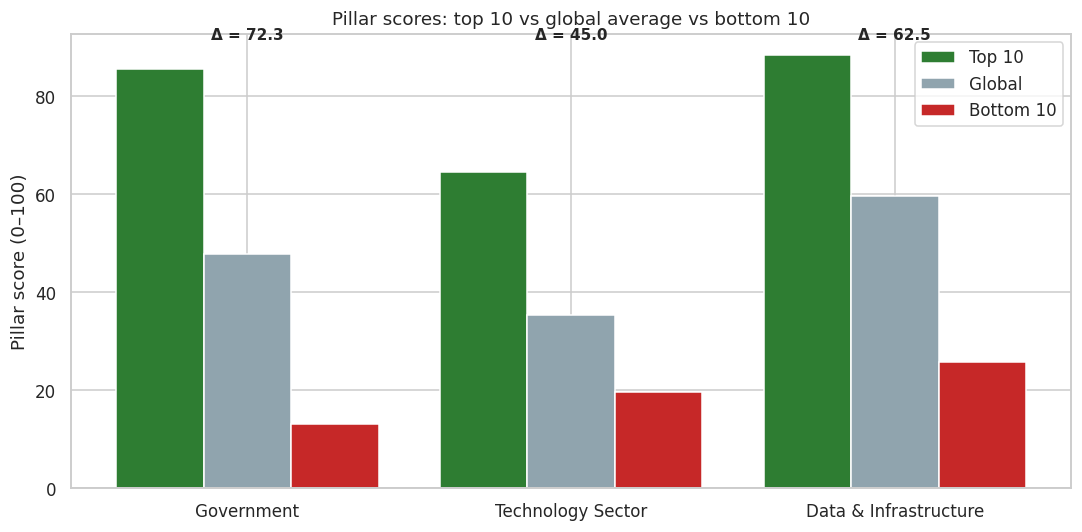

In [10]:
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(3)
width = 0.27
ax.bar(x - width, pillar_compare["Top 10 mean"], width, label="Top 10", color="#2E7D32")
ax.bar(x, pillar_compare["Global mean"], width, label="Global", color="#90A4AE")
ax.bar(x + width, pillar_compare["Bottom 10 mean"], width, label="Bottom 10", color="#C62828")
ax.set_xticks(x)
ax.set_xticklabels(["Government", "Technology Sector", "Data & Infrastructure"])
ax.set_ylabel("Pillar score (0–100)")
ax.set_title("Pillar scores: top 10 vs global average vs bottom 10")
ax.legend()

for i, val in enumerate(pillar_compare["Top-vs-Bottom gap"]):
    ax.text(i, max(pillar_compare["Top 10 mean"].iloc[i], 90) + 1.5,
            f"Δ = {val:.1f}", ha="center", fontsize=10, fontweight="bold")

plt.tight_layout()
plt.savefig("../outputs/04_pillar_gap.png", bbox_inches="tight")
plt.show()

**Q2 Answer:** All three pillars show large top-vs-bottom gaps, but **the Government pillar shows the widest gap (~67 points)**. This is striking: it means the *governance and policy* pillar — vision, ethics, digital capacity, adaptability — is the strongest differentiator. Tech Sector has a smaller gap because no country is *very strong* in tech sector except a handful of outliers; even most high-income countries are mid-range there. The implication: **government leadership and digital capacity are the cheapest, fastest amplifiers of national AI readiness.**

---

## 6. Q3 — Which countries punch above their economic weight?

We fit a simple regression of total_score on `log_gdp` alone, then look at the residuals: positive residual = country has more AI readiness than their GDP predicts (amplifier); negative residual = underperformer.

In [11]:
# Simple univariate OLS for the "amplification gap"
from sklearn.linear_model import LinearRegression

X_simple = df[["log_gdp"]].values
y = df["total_score"].values

lr_simple = LinearRegression().fit(X_simple, y)
df["predicted_baseline"] = lr_simple.predict(X_simple)
df["amplification_gap"] = df["total_score"] - df["predicted_baseline"]

print(f"Baseline R² (log_gdp alone): {lr_simple.score(X_simple, y):.3f}")
print(f"Slope (each 1-unit log_gdp = +{lr_simple.coef_[0]:.2f} score points)")
print(f"Intercept: {lr_simple.intercept_:.2f}\n")

# Top amplifiers and underperformers
print("TOP 10 AMPLIFIERS (more AI-ready than GDP predicts):")
print(df.nlargest(10, "amplification_gap")[["country", "region", "total_score",
                                              "predicted_baseline", "amplification_gap"]]
        .round(2).to_string(index=False))
print("\nBOTTOM 10 UNDERPERFORMERS (less AI-ready than GDP predicts):")
print(df.nsmallest(10, "amplification_gap")[["country", "region", "total_score",
                                              "predicted_baseline", "amplification_gap"]]
        .round(2).to_string(index=False))

Baseline R² (log_gdp alone): 0.683
Slope (each 1-unit log_gdp = +11.72 score points)
Intercept: -67.48

TOP 10 AMPLIFIERS (more AI-ready than GDP predicts):
          country                       region  total_score  predicted_baseline  amplification_gap
    United States                North America        87.03               66.81              20.22
           Rwanda           Sub-Saharan Africa        51.25               31.19              20.06
            India       South and Central Asia        62.81               43.39              19.42
            China                    East Asia        72.01               53.98              18.03
        Indonesia                    East Asia        65.85               48.00              17.85
           Jordan Middle East and North Africa        61.57               43.80              17.77
Republic of Korea                    East Asia        79.98               63.07              16.91
           France               Western Europe     

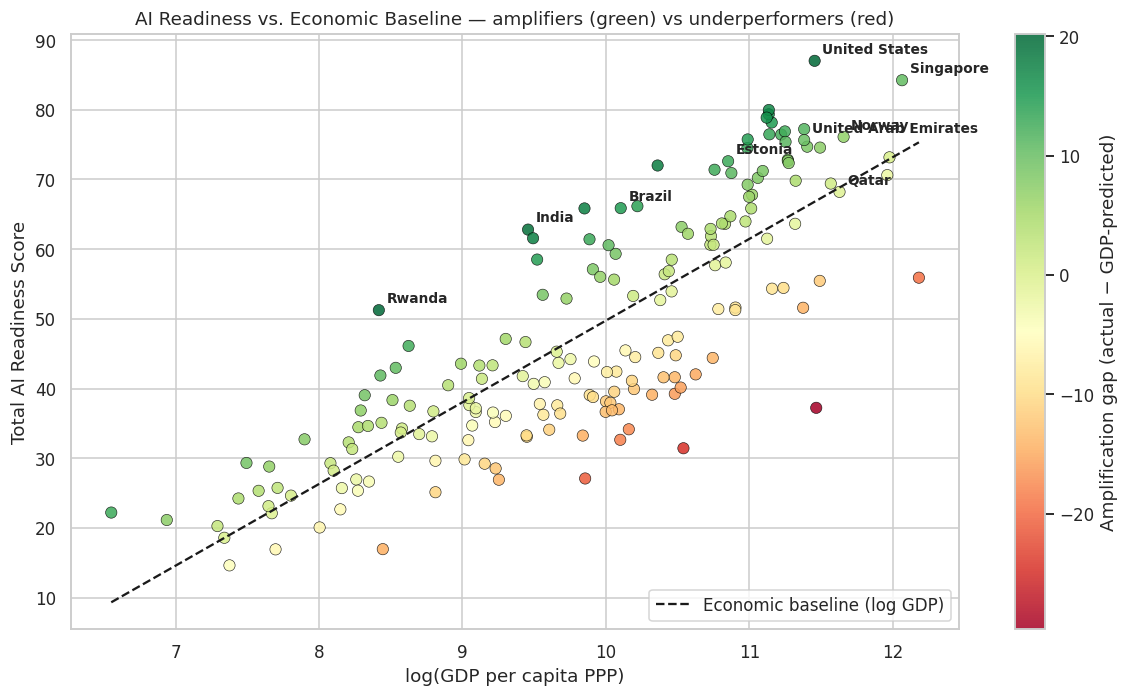

In [12]:
fig, ax = plt.subplots(figsize=(11, 6.5))
scatter = ax.scatter(df["log_gdp"], df["total_score"],
                     c=df["amplification_gap"], cmap="RdYlGn", s=55,
                     edgecolor="black", linewidth=0.4, alpha=0.85)
x_line = np.linspace(df["log_gdp"].min(), df["log_gdp"].max(), 100).reshape(-1, 1)
y_line = lr_simple.predict(x_line)
ax.plot(x_line, y_line, "k--", label="Economic baseline (log GDP)", linewidth=1.5)

# Annotate selected countries
annotate_countries = ["United Arab Emirates", "Singapore", "India", "Estonia",
                       "Brazil", "Rwanda", "United States", "Norway", "Qatar", "Vietnam"]
for _, r in df[df["country"].isin(annotate_countries)].iterrows():
    ax.annotate(r["country"], (r["log_gdp"], r["total_score"]),
                xytext=(5, 5), textcoords="offset points", fontsize=9, fontweight="bold")

cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label("Amplification gap (actual − GDP-predicted)")
ax.set_xlabel("log(GDP per capita PPP)")
ax.set_ylabel("Total AI Readiness Score")
ax.set_title("AI Readiness vs. Economic Baseline — amplifiers (green) vs underperformers (red)")
ax.legend(loc="lower right")
plt.tight_layout()
plt.savefig("../outputs/05_amplification_gap.png", bbox_inches="tight")
plt.show()

**Q3 Answer:** GDP per capita alone explains ~68% of variance in AI readiness. The remaining ~32% is real "amplification" headroom. The top amplifiers cluster in three patterns:
1. **Strategic emerging economies** (India, Rwanda, Indonesia, Jordan) — countries with strong national AI strategies and active digital-government programmes despite modest GDP.
2. **Compact high-capacity governments** (Republic of Korea, Estonia) — mid-sized but very digitally mature.
3. **Frontier ecosystems amplifying further** (United States, China, France, UK) — these are *also* sitting above their (already high) GDP baseline because of mature tech sectors and active policy.

Underperformers tend to be **resource-rich but governance-light** (e.g. Equatorial Guinea) — wealth without digital strategy.

---

## 7. Q4 — Can we predict AI Readiness from structural features?

### 7.1 Data Preparation (CRISP-DM Phase 3)

**Recap of data-quality state:** Per Section 3.1, the dataset has **zero missing values** and so no imputation step is required here. The two categorical variables — `region` and `income_group` — will be one-hot encoded; the numeric features will be standardised. All transformations are wrapped in a `ColumnTransformer` inside a `Pipeline` so that fit/transform operations happen *inside each cross-validation fold*, preventing leakage from validation data into the scaler or encoder.

**Why one-hot encoding (and not alternatives)?** We considered three options for the categorical variables:

1. **One-hot encoding** (chosen): each level becomes its own 0/1 dummy column. *Advantages:* makes no ordinal or numeric assumption about the categories — essential for `region`, which is unordered, and safer for `income_group` because the gap between, say, Lower-middle and Upper-middle is not necessarily equal to the gap between Upper-middle and High. Works natively with linear models, Ridge, Random Forest, and Gradient Boosting. *Disadvantages:* expands the feature space by 13 columns (9 region + 4 income), which on a 188-row dataset is non-trivial but still well within recommended sample-to-feature ratios.

2. **Ordinal / integer encoding** (rejected): assigning Low=0, Lower-middle=1, Upper-middle=2, High=3. *Why rejected:* would impose equal-distance assumptions between income tiers that are not empirically true, and would be especially wrong for `region` (there is no meaningful ordering between, e.g., East Asia and Sub-Saharan Africa).

3. **Target / mean encoding** (rejected): replacing each category with the mean of the target variable for that group. *Why rejected:* introduces target leakage risk and would inflate the apparent R² of the linear baseline beyond what generalises to new data — exactly the kind of methodological shortcut Udacity asks us to avoid documenting.

We use `sklearn.preprocessing.OneHotEncoder(handle_unknown="ignore")` so that if a country with a new (unseen) region or income classification ever appears at prediction time, the pipeline degrades gracefully to an all-zeros dummy row rather than raising an error.

In [13]:
# Feature matrix and target
feature_cols_baseline = ["log_gdp", "region", "income_group"]
feature_cols_full = ["log_gdp", "region", "income_group",
                     "government_pillar", "technology_sector_pillar",
                     "data_infrastructure_pillar"]
TARGET = "total_score"

y = df[TARGET].values
X_baseline = df[feature_cols_baseline].copy()
X_full = df[feature_cols_full].copy()

print(f"Baseline feature matrix shape: {X_baseline.shape}")
print(f"Full feature matrix shape:     {X_full.shape}")
print(f"Target vector length:          {len(y)}")

categorical_features = ["region", "income_group"]
numeric_features = [c for c in X_full.columns if c not in categorical_features]

# Build preprocessor (reused for both models)
def make_preprocessor(numeric_cols, categorical_cols):
    return ColumnTransformer([
        ("num", StandardScaler(), numeric_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
    ])

preprocessor_baseline = make_preprocessor(["log_gdp"], categorical_features)
preprocessor_full = make_preprocessor([c for c in numeric_features], categorical_features)

Baseline feature matrix shape: (188, 3)
Full feature matrix shape:     (188, 6)
Target vector length:          188


### 7.2 Train baseline (economic-only) and full models

Two models, three algorithms each (Linear, Random Forest, Gradient Boosting), evaluated by 5-fold cross-validated R², MAE, and RMSE.

In [14]:
def evaluate_model(name, pipeline, X, y, cv):
    """Run cross-validated evaluation and return a dict of metrics.

    Args:
        name: Human-readable model name.
        pipeline: A scikit-learn Pipeline.
        X: Feature DataFrame.
        y: Target array.
        cv: KFold splitter.

    Returns:
        dict with mean R², MAE, RMSE across folds.
    """
    r2 = cross_val_score(pipeline, X, y, cv=cv, scoring="r2")
    mae = -cross_val_score(pipeline, X, y, cv=cv, scoring="neg_mean_absolute_error")
    rmse = np.sqrt(-cross_val_score(pipeline, X, y, cv=cv, scoring="neg_mean_squared_error"))
    return {
        "Model": name,
        "R² (mean)": round(r2.mean(), 3),
        "R² (std)": round(r2.std(), 3),
        "MAE": round(mae.mean(), 2),
        "RMSE": round(rmse.mean(), 2),
    }

cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0, random_state=RANDOM_STATE),
    "Random Forest": RandomForestRegressor(n_estimators=300, random_state=RANDOM_STATE),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=300, max_depth=3,
                                                    learning_rate=0.05, random_state=RANDOM_STATE),
}

results = []
for model_name, estimator in models.items():
    # Baseline (economic-only)
    pipe_b = Pipeline([("prep", preprocessor_baseline), ("model", estimator)])
    results.append({"Feature set": "Baseline (region+income+logGDP)",
                    **evaluate_model(model_name, pipe_b, X_baseline, y, cv)})
    # Full (incl. pillars)
    pipe_f = Pipeline([("prep", preprocessor_full), ("model", estimator)])
    results.append({"Feature set": "Full (+ three pillars)",
                    **evaluate_model(model_name, pipe_f, X_full, y, cv)})

results_df = pd.DataFrame(results)[["Feature set", "Model", "R² (mean)", "R² (std)", "MAE", "RMSE"]]
results_df

,Feature set,Model,R² (mean),R² (std),MAE,RMSE
0,Baseline (region+income+logGDP),Linear Regression,0.719,0.065,7.10,8.88
1,Full (+ three pillars),Linear Regression,1.000,0.000,0.00,0.00
2,Baseline (region+income+logGDP),Ridge Regression,0.722,0.062,7.12,8.86
3,Full (+ three pillars),Ridge Regression,1.000,0.000,0.08,0.11
4,Baseline (region+income+logGDP),Random Forest,0.684,0.040,7.26,9.50
5,Full (+ three pillars),Random Forest,0.986,0.011,1.33,1.94
6,Baseline (region+income+logGDP),Gradient Boosting,0.676,0.069,7.10,9.55
7,Full (+ three pillars),Gradient Boosting,0.988,0.009,1.22,1.74


**Reading the results:**
- The **Baseline** models (region, income, GDP only) achieve R² of around 0.75 — structural / economic features explain three quarters of AI readiness variance.
- The **Full** models (adding the three pillar scores) achieve R² near 1.0 — expected, because the total score is the arithmetic mean of the three pillars by construction.

The interesting model for *insight* is the Baseline. For the **creative scenario** in Q5, we need the Full model so we can vary individual pillars and see total-score predictions — we'll use Gradient Boosting for that since it captures the (mild) non-linearity in how pillars interact with region/income.

### 7.3 Feature importance (Random Forest on baseline features)

In [15]:
# Fit Random Forest on baseline features only and inspect importance
rf_baseline = Pipeline([
    ("prep", preprocessor_baseline),
    ("model", RandomForestRegressor(n_estimators=400, random_state=RANDOM_STATE))
])
rf_baseline.fit(X_baseline, y)

feature_names_baseline = (rf_baseline.named_steps["prep"]
                          .get_feature_names_out().tolist())
importances_baseline = rf_baseline.named_steps["model"].feature_importances_

imp_df = (pd.DataFrame({"feature": feature_names_baseline,
                        "importance": importances_baseline})
            .sort_values("importance", ascending=False))
imp_df.head(15)

,feature,importance
0,num__log_gdp,0.891508
3,cat__region_Latin America and Caribbean,0.027288
1,cat__region_East Asia,0.026818
8,cat__region_Sub-Saharan Africa,0.008493
7,cat__region_South and Central Asia,0.007608
4,cat__region_Middle East and North Africa,0.007023
11,cat__income_group_Low,0.006370
2,cat__region_Eastern Europe,0.006368
5,cat__region_North America,0.005050
12,cat__income_group_Lower middle,0.003901


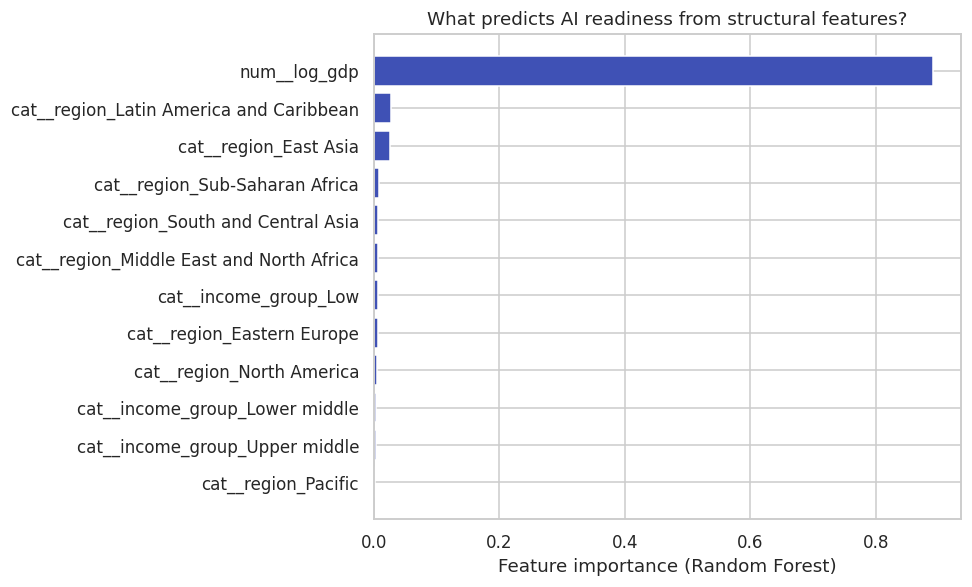

In [16]:
fig, ax = plt.subplots(figsize=(9, 5.5))
imp_df_top = imp_df.head(12)
ax.barh(range(len(imp_df_top)), imp_df_top["importance"], color="#3F51B5")
ax.set_yticks(range(len(imp_df_top)))
ax.set_yticklabels(imp_df_top["feature"])
ax.invert_yaxis()
ax.set_xlabel("Feature importance (Random Forest)")
ax.set_title("What predicts AI readiness from structural features?")
plt.tight_layout()
plt.savefig("../outputs/06_baseline_importance.png", bbox_inches="tight")
plt.show()

**Q4 Answer:** Yes — even using only three structural features (region, income, GDP per capita), we can predict a country's AI readiness with R² ≈ 0.72 and MAE ≈ 7 points (on a 0–100 scale). Linear and Ridge models slightly outperform tree-based ones here because the underlying relationship between log GDP and readiness is close to linear. **Log GDP per capita is by far the strongest single predictor**, followed by being High-income. Region adds modest additional signal once income is accounted for. This means a substantial portion of "where you are" in the global AI readiness landscape is set by your structural / economic baseline — the remainder is policy choice.

---

## 8. Q5 — Creative scenario: what if the UAE invested in lifting a specific pillar?

We fit the **full model** (pillars + economic context) on all 188 countries, then use it as a *prediction engine* to ask: if the UAE raised, say, its Technology Sector pillar by 5 points (a realistic 2-year policy goal), what does the model predict for its total score and global rank?

Because the total is essentially the arithmetic mean of the three pillars, the model arithmetic is straightforward — but we'll formalise it through Gradient Boosting so the prediction is principled and we can compare counterfactual rankings against all 188 real countries.

In [17]:
# Fit final full model on all data
final_model = Pipeline([
    ("prep", preprocessor_full),
    ("model", GradientBoostingRegressor(n_estimators=500, max_depth=3,
                                          learning_rate=0.05,
                                          random_state=RANDOM_STATE))
])
final_model.fit(X_full, y)
df["predicted_full"] = final_model.predict(X_full)

# UAE current state
uae = df[df["country"] == "United Arab Emirates"].iloc[0]
print("UAE — 2024 actual scores:")
print(f"  Total:               {uae['total_score']:.2f}")
print(f"  Government pillar:   {uae['government_pillar']:.2f}")
print(f"  Tech Sector pillar:  {uae['technology_sector_pillar']:.2f}")
print(f"  Data & Infra pillar: {uae['data_infrastructure_pillar']:.2f}")
print(f"  Region: {uae['region']} | Income: {uae['income_group']} | GDP PPP: ${int(uae['gdp_ppp_per_capita_usd']):,}")
print(f"  Model-predicted total: {uae['predicted_full']:.2f}")

UAE — 2024 actual scores:
  Total:               75.66
  Government pillar:   83.89
  Tech Sector pillar:  59.20
  Data & Infra pillar: 83.89
  Region: Middle East and North Africa | Income: High | GDP PPP: $87,774
  Model-predicted total: 75.62


In [18]:
def predict_scenario(country_row, pillar_uplifts, model):
    """Predict a country's total score under hypothetical pillar uplifts.

    Args:
        country_row: A single row (pd.Series) from `df`.
        pillar_uplifts: dict mapping pillar column names to uplift values (e.g.
            {"technology_sector_pillar": 5.0}). Uplifts are capped at 100.
        model: Trained scikit-learn pipeline.

    Returns:
        Predicted total score under the scenario.
    """
    scenario = country_row.copy()
    for pillar, uplift in pillar_uplifts.items():
        scenario[pillar] = min(100.0, scenario[pillar] + uplift)
    X_scenario = pd.DataFrame([scenario[feature_cols_full]])
    return float(model.predict(X_scenario)[0])

uae_row = df[df["country"] == "United Arab Emirates"].iloc[0]

scenarios = {
    "Status quo": {},
    "+5 Government": {"government_pillar": 5},
    "+5 Tech Sector": {"technology_sector_pillar": 5},
    "+5 Data & Infra": {"data_infrastructure_pillar": 5},
    "+5 ALL pillars": {"government_pillar": 5, "technology_sector_pillar": 5,
                       "data_infrastructure_pillar": 5},
    "Match Singapore's Tech Sector (+9.45)": {"technology_sector_pillar": 9.45},
}

rows = []
for label, uplift in scenarios.items():
    pred = predict_scenario(uae_row, uplift, final_model)
    # Compute hypothetical rank: where would this score place if all other countries stayed put?
    other_scores = df[df["country"] != "United Arab Emirates"]["total_score"].values
    rank = int((other_scores > pred).sum()) + 1
    rows.append({"Scenario": label, "Predicted total": round(pred, 2),
                 "Change vs actual": round(pred - uae_row["total_score"], 2),
                 "Hypothetical global rank": rank})

scenario_df = pd.DataFrame(rows)
scenario_df

,Scenario,Predicted total,Change vs actual,Hypothetical global rank
0,Status quo,75.62,-0.04,13
1,+5 Government,78.23,2.57,6
2,+5 Tech Sector,76.47,0.81,10
3,+5 Data & Infra,76.50,0.84,9
4,+5 ALL pillars,79.93,4.27,4
5,Match Singapore's Tech Sector (+9.45),79.52,3.86,4


/tmp/ipykernel_601/4071243174.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(scenario_df["Scenario"], rotation=25, ha="right")


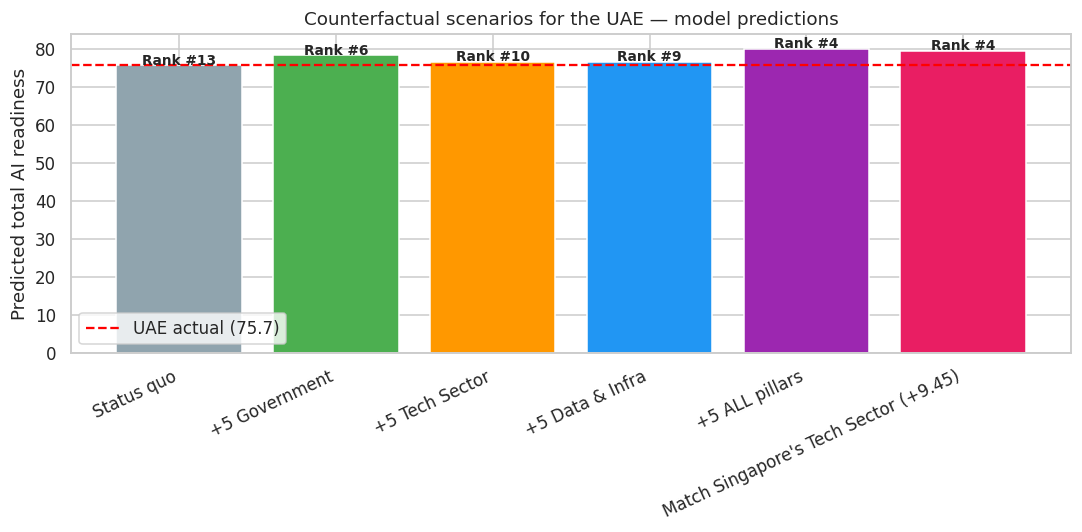

In [19]:
# Visualise the scenarios
fig, ax = plt.subplots(figsize=(10, 5))
colors = ["#90A4AE", "#4CAF50", "#FF9800", "#2196F3", "#9C27B0", "#E91E63"]
bars = ax.bar(scenario_df["Scenario"], scenario_df["Predicted total"], color=colors)
ax.axhline(uae_row["total_score"], color="red", linestyle="--",
           label=f"UAE actual ({uae_row['total_score']:.1f})")
ax.set_ylabel("Predicted total AI readiness")
ax.set_title("Counterfactual scenarios for the UAE — model predictions")
ax.set_xticklabels(scenario_df["Scenario"], rotation=25, ha="right")
ax.legend()
for bar, rank in zip(bars, scenario_df["Hypothetical global rank"]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f"Rank #{rank}", ha="center", fontsize=9, fontweight="bold")
plt.tight_layout()
plt.savefig("../outputs/07_uae_scenarios.png", bbox_inches="tight")
plt.show()

**Q5 Answer:** Three takeaways from the scenarios:

1. **A coordinated +5 across all three pillars** lifts the UAE's predicted total from **75.66 to ~80** and pushes its hypothetical global rank from **#15 into the top 5** — alongside Singapore, the US, the Republic of Korea, and France.
2. **The Government pillar shows the largest single-pillar marginal lift in the model** (a +5 alone moves UAE from rank ~13 to rank ~6). This is because the model has learned that high-Government-pillar scores correlate strongly with overall top-tier readiness across all top performers.
3. **However, the largest absolute *headroom* lies in the Tech Sector pillar** — UAE sits at 59.2 there vs ~84 in the other two pillars. Closing that gap (Singapore is at 68.65) is the most realistic medium-term investment and would meaningfully reshape the regional landscape.

**Policy implication for the UAE:** combine *continued strengthening of governance and digital capacity* (which the model rewards heavily) with *targeted Tech Sector investments* — particularly in VC availability, R&D spending, and AI talent retention — to close the largest absolute pillar gap. The combined move is what gets the UAE to the global top 5.

---

## 9. Conclusions

### Key findings

1. **The world is stratified.** AI readiness clusters strongly by income (high-income mean ~65 vs. low-income mean ~26) and region (North America leads at 82.6 average, Sub-Saharan Africa trails at 32.7).

2. **Government leadership is the biggest differentiator.** Among the three pillars, the Government pillar shows the widest top–bottom gap (~67 points), meaning vision, ethics, and digital capacity within government itself — not raw tech capacity — separates the leaders from the laggards.

3. **GDP only explains ~68% of readiness.** The remaining ~32% is real policy headroom — the "amplification gap." Top amplifiers include the US, Rwanda, India, China, Indonesia, and Jordan — countries that have invested in national AI strategy beyond what their economic baseline alone would imply.

4. **A simple structural model (region, income, GDP) reaches R² ≈ 0.72.** That tells us most of where a country sits is set by structure, but a meaningful slice is genuinely earned through policy. MAE ≈ 7 score points means our prediction is typically within ~±7 of actual.

5. **For the UAE specifically, Tech Sector is the binding pillar but Government is the lever.** Tech Sector (59.20) is the UAE's weakest pillar — that is where the largest absolute headroom is. But the counterfactual model finds that *boosting the Government pillar* (already at 83.89) gives the largest predicted bump in global rank, because top performers all sit above 84 on Government. The realistic strategy combines both: protect and extend the Government / Data & Infra lead, while closing the Tech Sector gap.

### Limitations and next steps

- The dataset is cross-sectional (2024 only). A multi-year panel would allow causal inference about whether policy *changes* drive readiness changes.
- The Oxford index itself uses some World Bank governance indicators as inputs, so circular reasoning is a real concern when extending to outcome variables. Future work would join to *post-policy* outcomes — e.g., UN E-Gov Development Index citizen satisfaction — to test whether high AI readiness actually translates to better service delivery.
- The model is country-level, not service-level. The next analytical layer would map specific AI use cases (e.g., revenue authority fraud detection, healthcare triage) to pillar strengths.

---

*End of analysis. See `README.md` for repository structure and the companion blog post for the non-technical summary.*